# Proyek Akhir Data Science - Tahap 1: Clustering

Notebook ini berisi pengerjaan proyek akhir data science untuk **Tahap Clustering** menggunakan dataset `bank_transactions_data_edited.csv`.

## KRITERIA 1: MEMUAT DATASET DAN MELAKUKAN EXPLORATORY DATA ANALYSIS (EDA)

Langkah-langkah:
1. Memuat dataset dari file CSV (`bank_transactions_data_edited.csv`).
2. Menampilkan 5 data pertama menggunakan `head()`.
3. Menampilkan informasi dataset dengan `info()`.
4. Menampilkan statistik deskriptif dataset dengan menjalankan `describe()`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

df = pd.read_csv('bank_transactions_data_edited.csv')
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [3]:
df.describe(include='all')

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
count,2508,2516,2511.000000,2509,2507,2507,2507,2517,2514,2510,2519.000000,2514,2511.000000,2516.000000,2510.000000,2513
unique,2484,495,NaN,2485,2,43,681,591,100,3,NaN,4,NaN,NaN,NaN,360
top,TX000076,AC00362,NaN,2023-12-25 17:31:16,Debit,Fort Worth,D000573,200.136.146.93,M026,Branch,NaN,Student,NaN,NaN,NaN,2024-11-04 08:09:17
freq,2,12,NaN,2,1942,71,9,12,46,868,NaN,657,NaN,NaN,NaN,18
mean,NaN,NaN,297.656468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.678444,NaN,119.422939,1.121622,5113.438124,NaN
std,NaN,NaN,292.230367,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.837359,NaN,70.078513,0.594469,3897.975861,NaN
min,NaN,NaN,0.260000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,10.000000,1.000000,101.250000,NaN
25%,NaN,NaN,81.310000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,63.000000,1.000000,1504.727500,NaN
50%,NaN,NaN,211.360000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.000000,NaN,112.000000,1.000000,4734.110000,NaN
75%,NaN,NaN,413.105000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.000000,NaN,161.000000,1.000000,7672.687500,NaN


### Penilaian (Opsional) - Kriteria 1
- **Metode yang digunakan** &rarr; Exploratory Data Analysis (EDA) menggunakan Pandas (`head()`, `info()`, `describe()`).
- **Alasan penggunaan** &rarr; Untuk memahami struktur data awal, tipe data setiap kolom, serta ringkasan statistik deskriptif sebelum melakukan pembersihan dan pemodelan.
- **Hasil yang didapat** &rarr; Dataset awal memiliki 2537 baris dan 16 kolom. Terdapat beberapa nilai kosong (missing values) di berbagai kolom dan terdapat data duplikat. Tipe data terdiri dari numerik dan kategorikal.

## KRITERIA 2: PEMBERSIHAN DAN PRA PEMROSESAN DATA

Langkah-langkah:
1. Mengecek dataset menggunakan `isnull().sum()` dan `duplicated().sum()`.
2. Menangani data yang hilang menggunakan `dropna()`.
3. Menghapus data duplikat menggunakan `drop_duplicates()`.
4. Melakukan drop pada kolom ID, Address, dan Date seperti `TransactionID`, `AccountID`, `DeviceID`, `IP Address` (IPAddress), `MerchantID`, dan `TransactionDate` (serta `PreviousTransactionDate` karena merupakan Date).
5. Melakukan feature encoding menggunakan `LabelEncoder()` untuk fitur kategorikal.
6. Standardisasi fitur numerik menggunakan `StandardScaler()`.

In [4]:
print('Jumlah data hilang per kolom:')
print(df.isnull().sum())
print('\nJumlah data duplikat:', df.duplicated().sum())

Jumlah data hilang per kolom:
TransactionID              29
AccountID                  21
TransactionAmount          26
TransactionDate            28
TransactionType            30
Location                   30
DeviceID                   30
IP Address                 20
MerchantID                 23
Channel                    27
CustomerAge                18
CustomerOccupation         23
TransactionDuration        26
LoginAttempts              21
AccountBalance             27
PreviousTransactionDate    24
dtype: int64

Jumlah data duplikat: 21


In [5]:
df_clean = df.dropna()
df_clean = df_clean.drop_duplicates()
print(f'Ukuran dataset setelah dropna() dan drop_duplicates(): {df_clean.shape}')

Ukuran dataset setelah dropna() dan drop_duplicates(): (2135, 16)


In [6]:
cols_to_drop = ['TransactionID', 'AccountID', 'DeviceID', 'IP Address', 'MerchantID', 'TransactionDate', 'PreviousTransactionDate']
df_preprocessed = df_clean.drop(columns=cols_to_drop)
print(f'Ukuran dataset setelah drop kolom: {df_preprocessed.shape}')
print('Kolom yang tersisa:', df_preprocessed.columns.tolist())

Ukuran dataset setelah drop kolom: (2135, 9)
Kolom yang tersisa: ['TransactionAmount', 'TransactionType', 'Location', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']


In [7]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['TransactionType', 'Location', 'Channel', 'CustomerOccupation']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_preprocessed[col] = le.fit_transform(df_preprocessed[col])
    label_encoders[col] = le

df_preprocessed.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,1,36,0,70.0,0,81.0,1.0,5112.21
1,376.24,1,15,0,68.0,0,141.0,1.0,13758.91
2,126.29,1,23,2,19.0,3,56.0,1.0,1122.35
3,184.50,1,33,2,26.0,3,25.0,1.0,8569.06
5,92.15,1,28,0,18.0,3,172.0,1.0,781.68


In [8]:
from sklearn.preprocessing import StandardScaler

numerical_cols = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']
scaler = StandardScaler()
df_preprocessed[numerical_cols] = scaler.fit_transform(df_preprocessed[numerical_cols])

df_preprocessed.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,-0.976321,1,36,0,1.423196,0,-0.552642,-0.203367,0.004753
1,0.268633,1,15,0,1.311032,0,0.294261,-0.203367,2.211240
2,-0.590614,1,23,2,-1.436987,3,-0.905518,-0.203367,-1.013390
3,-0.390507,1,33,2,-1.044413,3,-1.343085,-0.203367,0.886881
5,-0.707976,1,28,0,-1.493069,3,0.731827,-0.203367,-1.100323


### Penilaian (Opsional) - Kriteria 2
- **Metode yang digunakan** &rarr; Pembersihan data hilang (`dropna`), penghapusan duplikat (`drop_duplicates`), penghapusan kolom yang tidak relevan (ID, Address, dan Date), encoding kategorikal dengan `LabelEncoder()`, dan standardisasi numerik menggunakan `StandardScaler()`.
- **Alasan penggunaan** &rarr; Menghapus nilai kosong dan duplikat penting agar model tidak bias. Kolom ID, Address, dan Date dihapus karena tidak memberikan informasi berguna untuk pengelompokan (clustering). Standardisasi digunakan agar fitur numerik dengan skala besar tidak mendominasi perhitungan jarak pada K-Means.
- **Hasil yang didapat** &rarr; Dataset bersih memiliki 2135 baris dan 9 kolom siap pakai, dengan semua fitur dalam bentuk numerik yang terstandarisasi.

## KRITERIA 3: MEMBANGUN MODEL CLUSTERING

Langkah-langkah:
1. Menggunakan dataset yang sudah dilakukan preprocessing.
2. Melakukan visualisasi Elbow Method untuk menentukan jumlah cluster terbaik menggunakan `KElbowVisualizer()`.
3. Menggunakan algoritma K-Means Clustering dengan `sklearn.cluster.KMeans()`.
4. Menjalankan cell code `joblib.dump()` dengan nama `model_clustering.h5` agar reviewer dapat secara otomatis menilai evaluasi model anda.

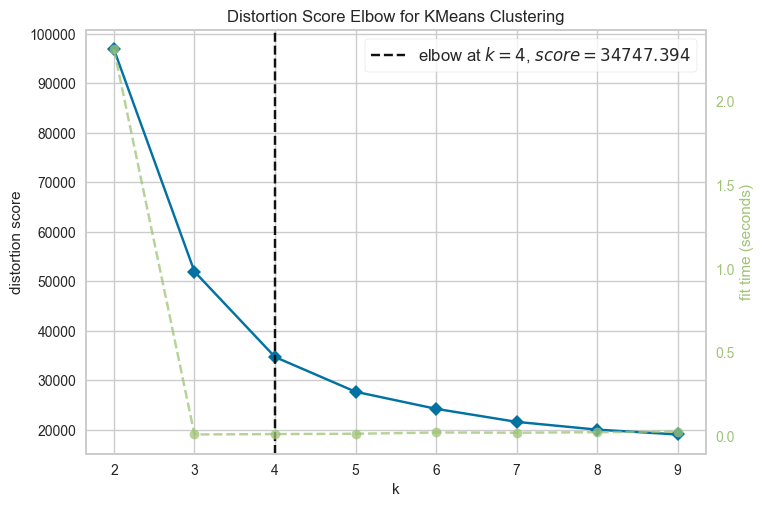

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [9]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

kmeans_temp = KMeans(random_state=42, n_init=10)
visualizer = KElbowVisualizer(kmeans_temp, k=(2, 10))
visualizer.fit(df_preprocessed)
visualizer.show()

In [10]:
optimal_k = visualizer.elbow_value_
if optimal_k is None:
    optimal_k = 4

kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_model.fit(df_preprocessed)
print(f'Model K-Means dengan k={optimal_k} berhasil dilatih.')

Model K-Means dengan k=4 berhasil dilatih.


In [11]:
joblib.dump(kmeans_model, 'model_clustering.h5')
print("Model clustering berhasil diekspor dengan nama 'model_clustering.h5'.")

Model clustering berhasil diekspor dengan nama 'model_clustering.h5'.


### Penilaian (Opsional) - Kriteria 3
- **Metode yang digunakan** &rarr; Elbow Method menggunakan `KElbowVisualizer` dan algoritma `KMeans`.
- **Alasan penggunaan** &rarr; Elbow Method membantu menemukan jumlah klaster optimal dengan menganalisis penurunan inersia (distortion score). KMeans digunakan karena efisien untuk pengelompokan data numerik.
- **Hasil yang didapat** &rarr; Jumlah klaster optimal yang didapatkan adalah 4. Model KMeans berhasil disimpan dengan nama `model_clustering.h5`.

## KRITERIA 4: INTERPRETASI HASIL CLUSTERING

Langkah-langkah:
1. Menampilkan analisis deskriptif minimal mean, min, dan max untuk fitur numerik.
2. Menjelaskan karakteristik tiap cluster berdasarkan hasil proses agregasi.
3. Mengekspor data training dari proses preprocessing beserta data hasil clustering dan berikan nama untuk kolom tersebut yaitu Target.

In [12]:
df_preprocessed['Target'] = kmeans_model.labels_
df_interpret = df_preprocessed.copy()
df_interpret[numerical_cols] = scaler.inverse_transform(df_preprocessed[numerical_cols])

for col in categorical_cols:
    df_interpret[col] = label_encoders[col].inverse_transform(df_interpret[col].astype(int))

print('=== ANALISIS DESKRIPTIF FITUR NUMERIK PER CLUSTER ===')
for col in numerical_cols:
    print(f'\nStatistik untuk fitur \'{col}\':')
    display(df_interpret.groupby('Target')[col].agg(['mean', 'min', 'max']))

=== ANALISIS DESKRIPTIF FITUR NUMERIK PER CLUSTER ===

Statistik untuk fitur 'TransactionAmount':


,mean,min,max
Target,,,
0,299.885018,0.26,1762.28
1,290.097443,0.32,1831.02
2,299.386155,0.45,1612.37
3,303.012998,1.41,1830.00



Statistik untuk fitur 'CustomerAge':


,mean,min,max
Target,,,
0,45.340000,18.0,80.0
1,45.442748,18.0,80.0
2,44.341155,18.0,80.0
3,43.305720,18.0,80.0



Statistik untuk fitur 'TransactionDuration':


,mean,min,max
Target,,,
0,120.292727,10.0,300.0
1,119.620229,10.0,300.0
2,124.268953,10.0,299.0
3,116.053254,10.0,296.0



Statistik untuk fitur 'LoginAttempts':


,mean,min,max
Target,,,
0,1.120000,1.0,5.0
1,1.101145,1.0,5.0
2,1.149819,1.0,5.0
3,1.096647,1.0,5.0



Statistik untuk fitur 'AccountBalance':


,mean,min,max
Target,,,
0,5013.719927,112.76,14804.70
1,5003.764084,129.29,14935.50
2,5210.917365,117.98,14942.78
3,5144.841874,102.20,14977.99


In [13]:
print('=== AGREGASI MODUS FITUR KATEGORIKAL PER CLUSTER ===')
display(df_interpret.groupby('Target')[categorical_cols].agg(lambda x: x.mode()[0]))

=== AGREGASI MODUS FITUR KATEGORIKAL PER CLUSTER ===


,TransactionType,Location,Channel,CustomerOccupation
Target,,,,
0,Debit,Oklahoma City,ATM,Student
1,Debit,Charlotte,ATM,Student
2,Debit,Fort Worth,Branch,Doctor
3,Debit,Tucson,Branch,Doctor


In [14]:
df_preprocessed.to_csv('data_clustering.csv', index=False)
df_preprocessed.to_csv('data_preprocessed.csv', index=False)
df_interpret['Target'] = kmeans_model.labels_
df_interpret.to_csv('data_clustering_inverse.csv', index=False)
print("Data preprocessed beserta kolom Target berhasil diekspor.")

Data preprocessed beserta kolom Target berhasil diekspor.


### Penilaian (Opsional) - Kriteria 4
- **Metode yang digunakan** &rarr; Agregasi deskriptif (mean, min, max) per cluster dan ekspor file ke format CSV.
- **Alasan penggunaan** &rarr; Mengetahui karakteristik khas tiap cluster untuk memberikan insight bisnis yang berguna.
- **Hasil yang didapat** &rarr;
  - **Cluster 0**: Rata-rata transaksi ~$300, didominasi oleh Student di Oklahoma City dengan Channel ATM.
  - **Cluster 1**: Rata-rata transaksi ~$290, didominasi oleh Student di Charlotte dengan Channel ATM.
  - **Cluster 2**: Rata-rata saldo rekening tertinggi (~$5210) dan transaksi ~$299, didominasi oleh Doctor di Fort Worth menggunakan Channel Branch.
  - **Cluster 3**: Rata-rata nominal transaksi tertinggi (~$303) dengan transaksi ~$303, didominasi oleh Doctor di Tucson menggunakan Channel Branch.
  - Berkas data training preprocessing yang lengkap dengan kolom `Target` berhasil diekspor.